In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dataOriginal = pd.read_csv('adult income dataset.csv')
dataOriginal.head()

,Age,Workclass,Final Weight,Education,Education Number of Years,Marital-status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
dataOriginal.shape

(48842, 15)

In [ ]:
dataOriginal.isnull().sum()

,0
Age,0
Workclass,0
Final Weight,0
Education,0
Education Number of Years,0
Marital-status,0
Occupation,0
Relationship,0
Race,0
Sex,0


In [ ]:
#NEED TO DO MULTIPLE CHECKS FOR NULL BY LOOKING FOR "?"/ "N/A" "NaN" "Unknown"
#CLEAN‑UP & IMPUTATION

dataOriginal.replace(['?', 'N/A', 'Unknown'], np.nan, inplace=True)

#Identify column types
cat_cols = dataOriginal.select_dtypes(include='object').columns.tolist()
num_cols = dataOriginal.select_dtypes(exclude='object').columns.tolist()

#Impute missing values Categorical -> fill with MODE & Numerical -> fill with MEDIAN (so no outliers)

for col in cat_cols: # categorical loop
    dataOriginal[col].fillna(dataOriginal[col].mode()[0], inplace=True)

dataOriginal[num_cols] = dataOriginal[num_cols].fillna(
    dataOriginal[num_cols].median())  # numeric bulk‑fill

<ipython-input-122-f949a93f44ec>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataOriginal[col].fillna(dataOriginal[col].mode()[0], inplace=True)


In [ ]:
#any leftover NaNs chk
total_nans = dataOriginal.isnull().sum().sum()
print(f"Total NaNs remaining: {total_nans}")


Total NaNs remaining: 0


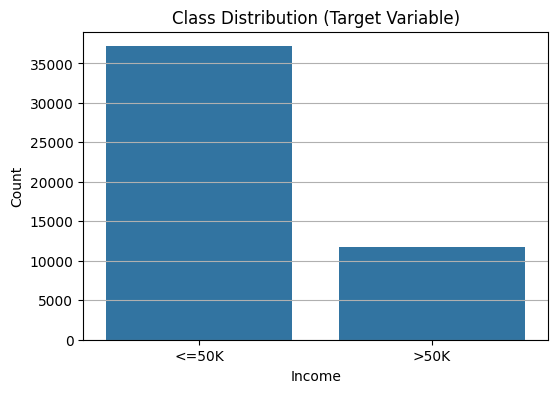

In [ ]:
#EDA-> class distribution of y
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=dataOriginal)
plt.title("Class Distribution (Target Variable)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["<=50K", ">50K"])
plt.grid(True, axis='y')
plt.show()

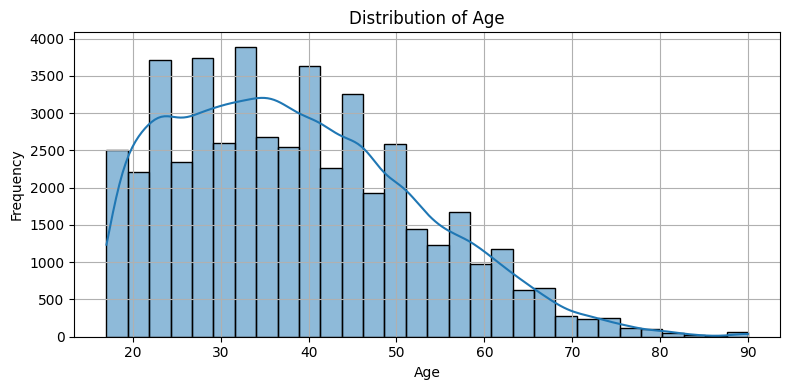

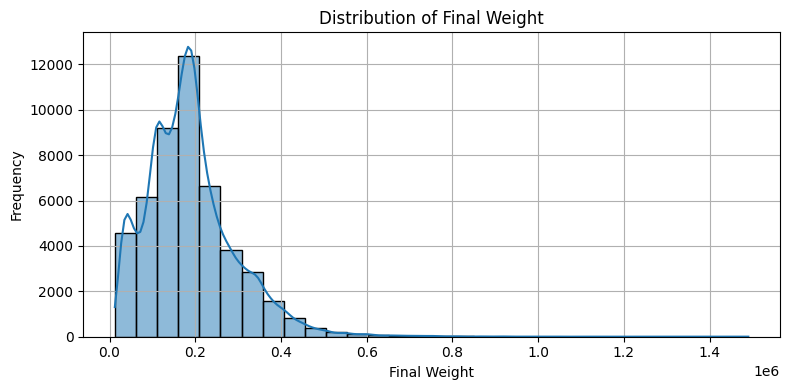

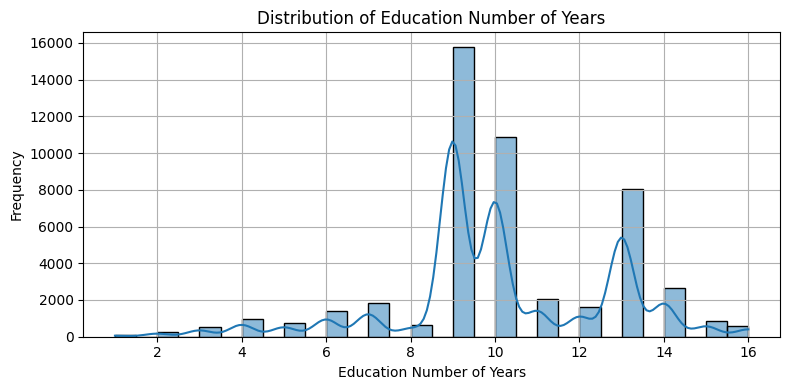

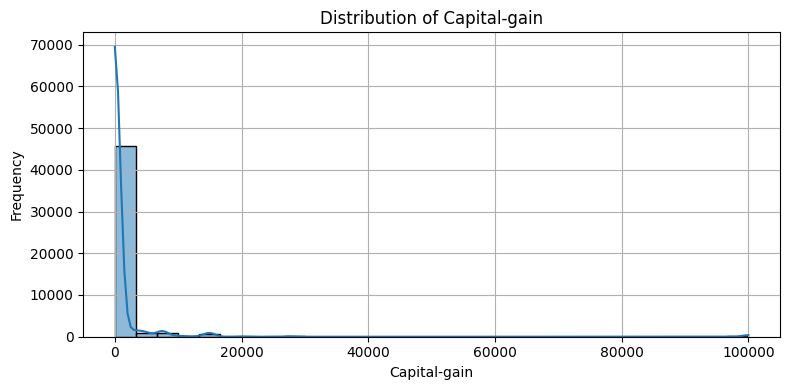

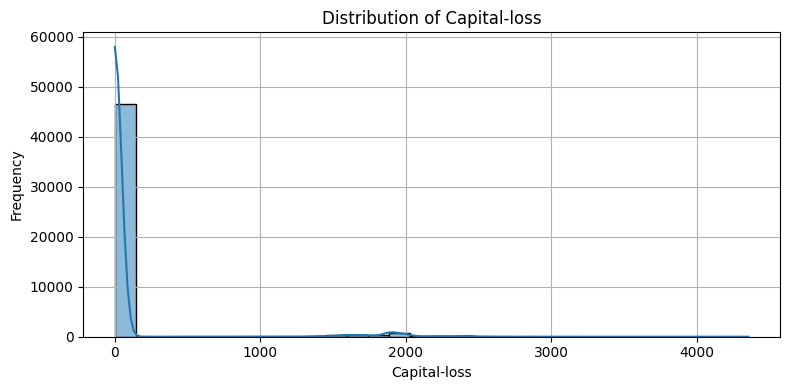

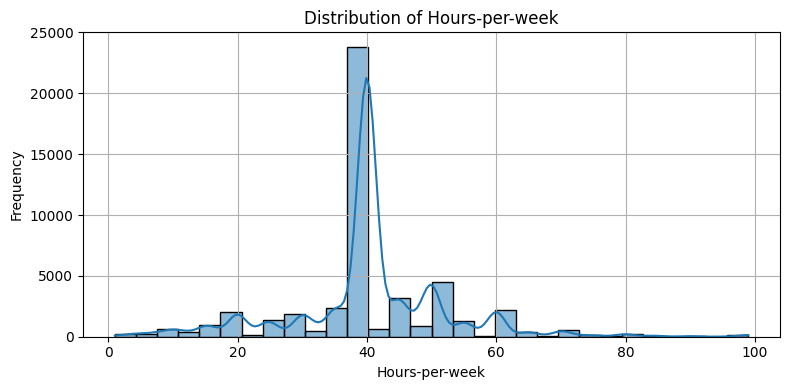

In [ ]:
#EDA-> Histogram
import matplotlib.pyplot as plt
import seaborn as sns

#histogram for each numeric feature
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(dataOriginal[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


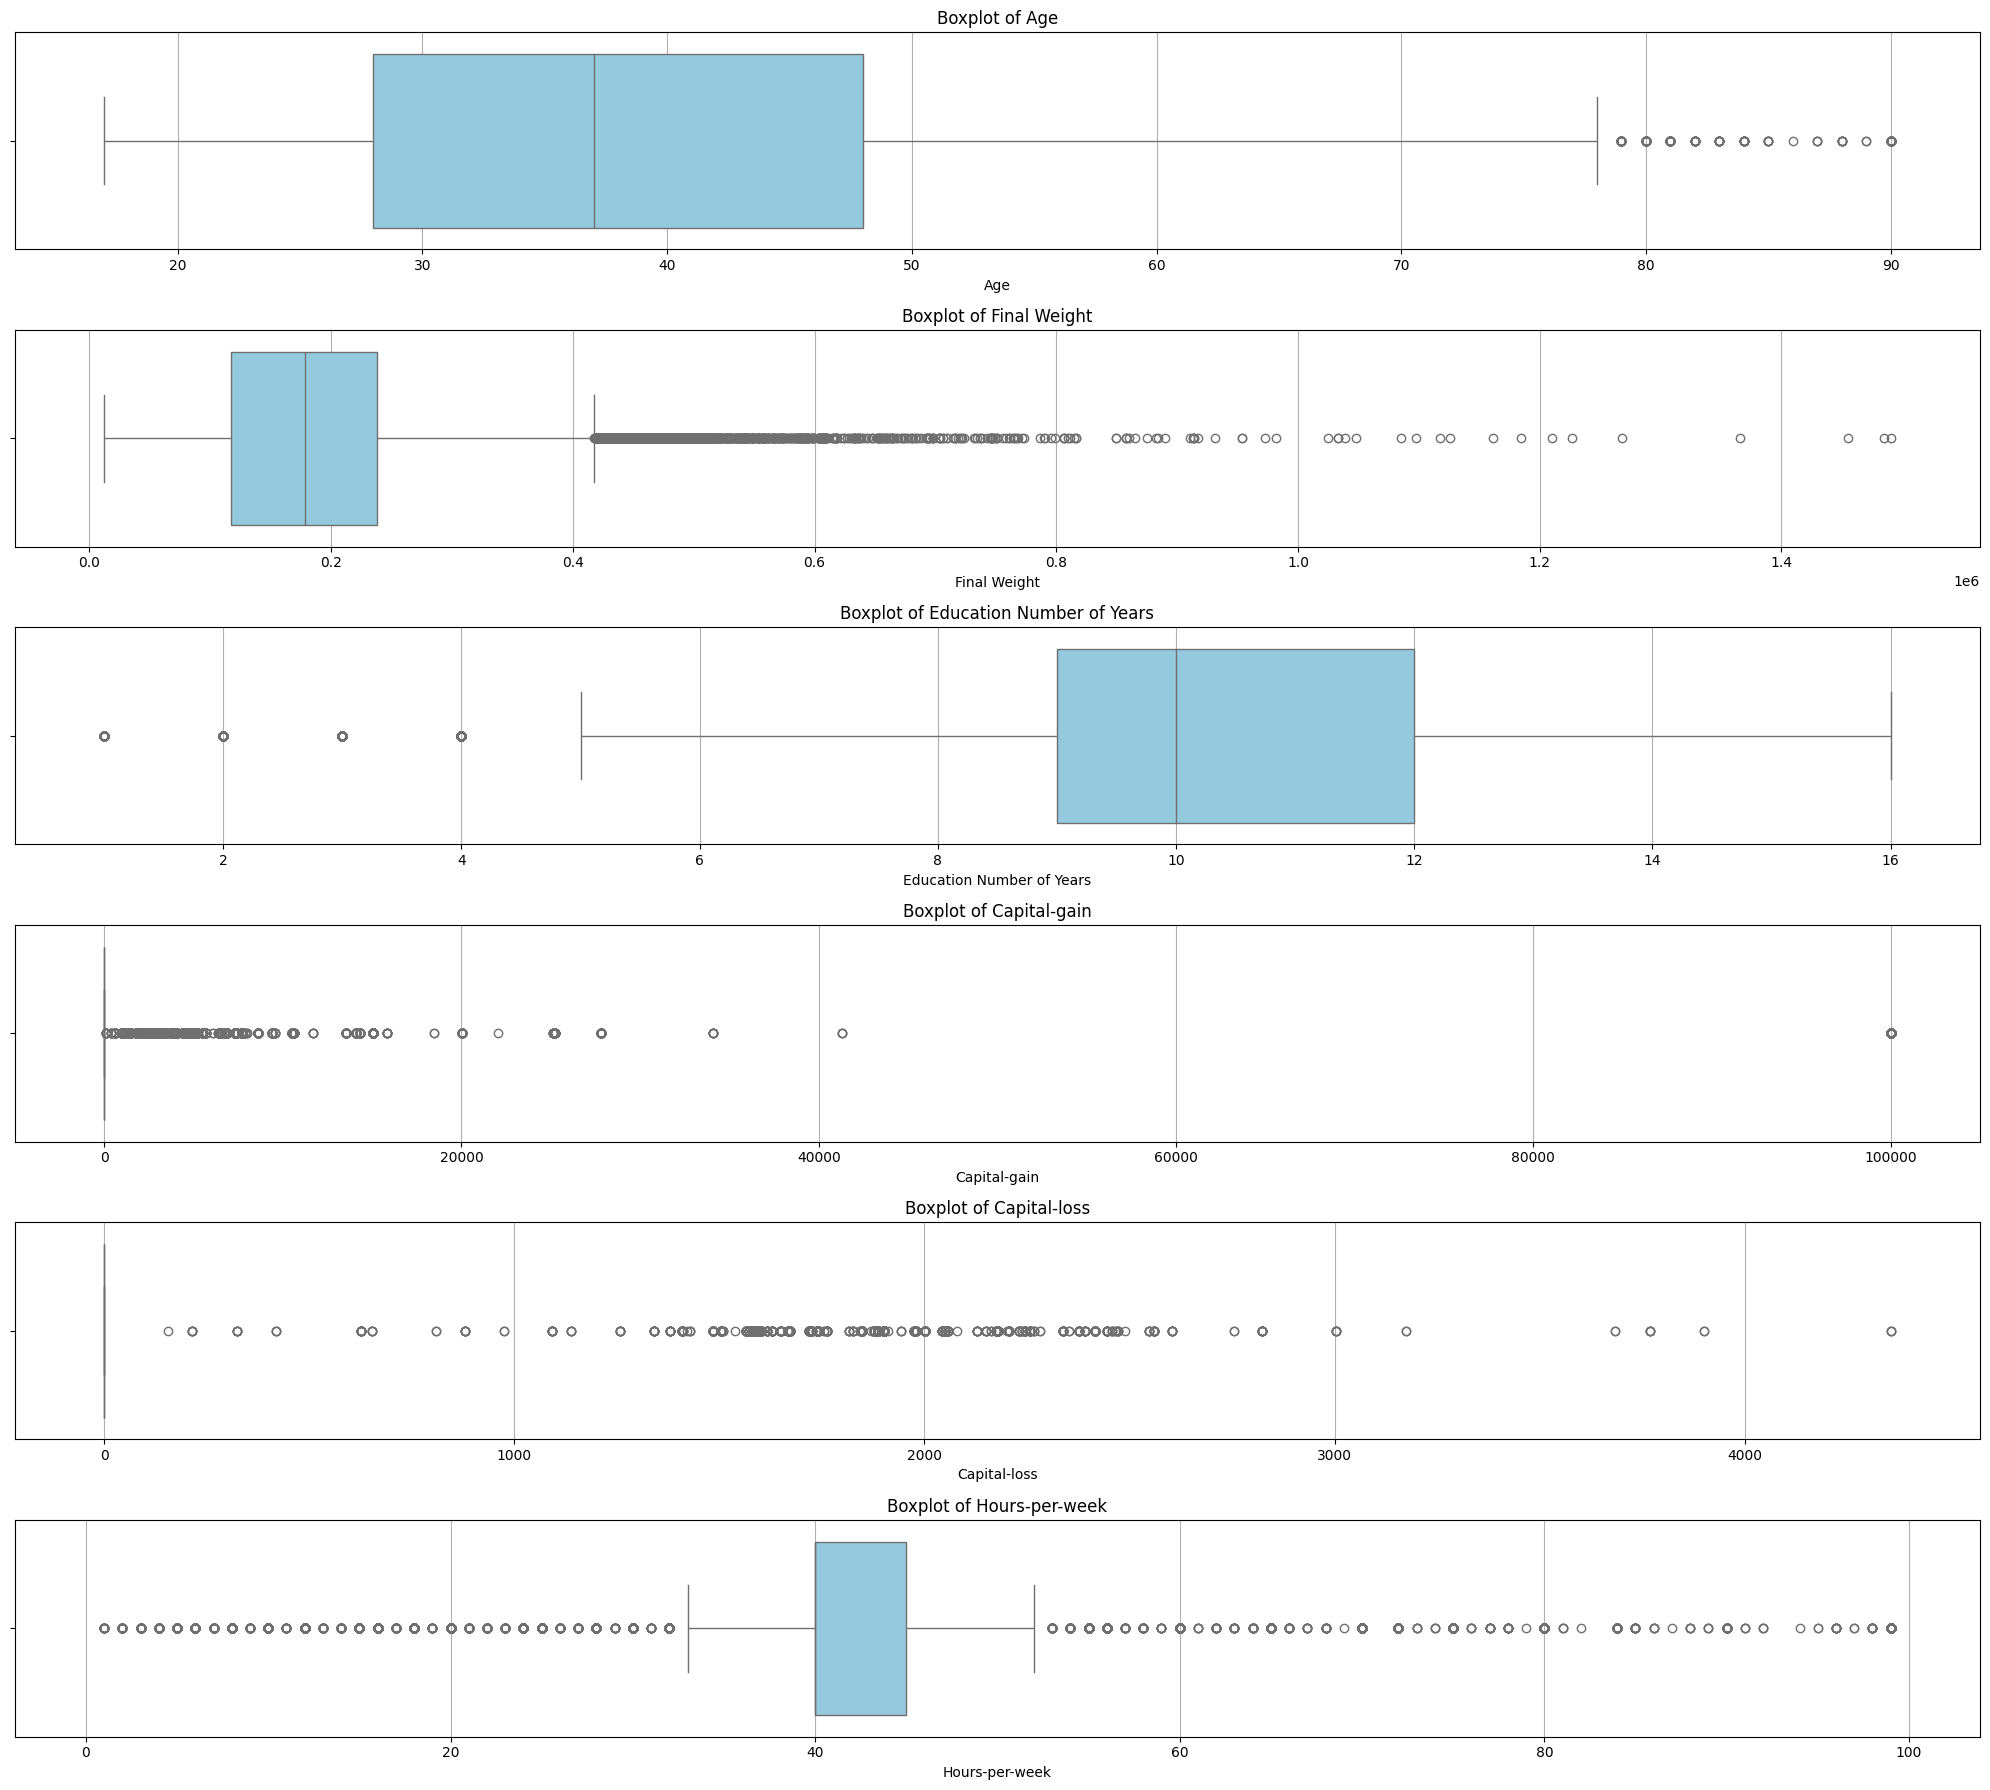

In [ ]:
#EDA-BOXPLOT
# BOX PLOT
plt.figure(figsize=(20, len(num_cols) * 3))

# boxplots for each numerical feature
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=dataOriginal[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col)
    plt.grid(True, axis='x')
    plt.tight_layout()

plt.show()


In [ ]:
##ENCODING
print("\nUnique values for each categorical column:\n")
for col in dataOriginal.columns:
    print(f"{col}: {dataOriginal[col].unique()}")

dataOriginal.shape


Unique values for each categorical column:

Age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89]
Workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Final Weight: [ 77516  83311 215646 ... 173449  89686 350977]
Education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Education Number of Years: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
Marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
Occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 '

(48842, 15)

In [ ]:
from sklearn.preprocessing import LabelEncoder

dataOriginal_enc = pd.get_dummies(
    dataOriginal,
    columns=['Workclass', 'Education', 'Marital-status',
             'Occupation', 'Relationship', 'Native-country']
)

# Label‑encode ->binary columns ('Sex', 'Race') and the target
from sklearn.preprocessing import LabelEncoder
label_cols = ['Sex', 'Race', 'target']
enc = LabelEncoder()
for col in label_cols:
    dataOriginal_enc[col] = enc.fit_transform(dataOriginal_enc[col])


total_nans = dataOriginal_enc.isnull().sum().sum()
print(f"\nTotal NaNs remaining after encoding: {total_nans}")  # should print 0

dataOriginal_enc.head()


Total NaNs remaining after encoding: 0


,Age,Final Weight,Education Number of Years,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,target,Workclass_Federal-gov,...,Native-country_Portugal,Native-country_Puerto-Rico,Native-country_Scotland,Native-country_South,Native-country_Taiwan,Native-country_Thailand,Native-country_Trinadad&Tobago,Native-country_United-States,Native-country_Vietnam,Native-country_Yugoslavia
0,39,77516,13,4,1,2174,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,4,1,0,0,13,0,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,4,1,0,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,2,1,0,0,40,0,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,2,0,0,0,40,0,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = dataOriginal_enc.drop(columns=['target'])
Y = dataOriginal_enc['target']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, stratify=Y ,random_state=19)           # <<< keeps the 76 / 24 ratio

#check if y is being stratified properly
print("y_train class ratio:", y_train.mean())
print("y_test  class ratio:", y_test.mean())


y_train class ratio: 0.23928749012840386
y_test  class ratio: 0.23926840919948134


In [ ]:
#NO SCALING
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train, y_train)


# scoring on the scaled test set
print("KNN test accuracy: {:.2f}".format(knn.score(X_test, y_test)))

KNN test accuracy: 0.78


In [ ]:
#ROBUST SCALING
# from sklearn.preprocessing import RobustScaler

# # Apply RobustScaler to all features
# scaler = RobustScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
from sklearn.preprocessing import RobustScaler

# Identify numeric columns again in the encoded frame
num_cols_enc = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols_enc] = scaler.fit_transform(X_train[num_cols_enc])
X_test_scaled[num_cols_enc]  = scaler.transform(X_test[num_cols_enc])


In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)


# scoring on the scaled test set
print("KNN test accuracy: {:.2f}".format(knn.score(X_test_scaled, y_test)))

KNN test accuracy: 0.86


                                Age  Final Weight  Education Number of Years  \
Age                        1.000000     -0.076628                   0.030940   
Final Weight              -0.076628      1.000000                  -0.038761   
Education Number of Years  0.030940     -0.038761                   1.000000   
Capital-gain               0.077229     -0.003706                   0.125146   
Capital-loss               0.056944     -0.004366                   0.080972   
Hours-per-week             0.071558     -0.013519                   0.143689   

                           Capital-gain  Capital-loss  Hours-per-week  
Age                            0.077229      0.056944        0.071558  
Final Weight                  -0.003706     -0.004366       -0.013519  
Education Number of Years      0.125146      0.080972        0.143689  
Capital-gain                   1.000000     -0.031441        0.082157  
Capital-loss                  -0.031441      1.000000        0.054467  
Hours-p

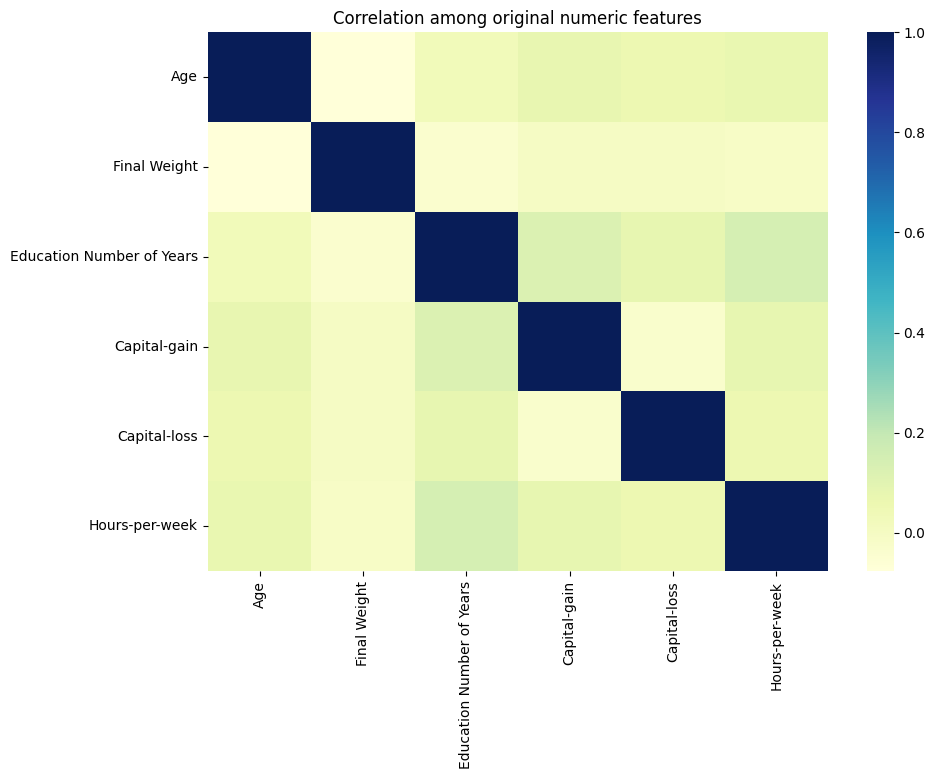

In [ ]:
# HEAT‑MAP ON ORIGINAL NUMERICS & DROP FEATURE IF MORE THAN .85
corr_matrix = dataOriginal[num_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt
print(corr_matrix)
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, cmap='YlGnBu')
plt.title("Correlation among original numeric features")
plt.show()


In [ ]:
#LOGISTIC REG
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')

logreg.fit(X_train_scaled, y_train)
print("LogReg test accuracy: {:.2f}".format(logreg.score(X_test_scaled, y_test)))


LogReg test accuracy: 0.81


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# NN
X_train_pp = X_train_scaled.astype('float32')
X_test_pp  = X_test_scaled.astype('float32')

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_pp.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])
nn.compile(optimizer='adam',
           loss='binary_crossentropy',
           metrics=['accuracy', AUC(name='auc')])

es = EarlyStopping(patience=4, restore_best_weights=True)

history = nn.fit(
    X_train_pp, y_train,
    validation_split=0.3,
    epochs=40, batch_size=128,
    callbacks=[es], verbose=1)

nn_loss, nn_acc, nn_auc = nn.evaluate(X_test_pp, y_test, verbose=0)
print(f"NN test accuracy: {nn_acc:.2f} | ROC‑AUC: {nn_auc:.2f}")


Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6888 - auc: 0.6416 - loss: 10.8987 - val_accuracy: 0.8097 - val_auc: 0.8583 - val_loss: 2.0592
Epoch 2/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8060 - auc: 0.8128 - loss: 4.6445 - val_accuracy: 0.8124 - val_auc: 0.8491 - val_loss: 2.5679
Epoch 3/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8129 - auc: 0.8255 - loss: 3.4693 - val_accuracy: 0.8125 - val_auc: 0.8099 - val_loss: 0.8491
Epoch 4/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8164 - auc: 0.8314 - loss: 2.4309 - val_accuracy: 0.8185 - val_auc: 0.8748 - val_loss: 0.4689
Epoch 5/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - auc: 0.8208 - loss: 1.9277 - val_accuracy: 0.7925 - val_auc: 0.7012 - val_loss: 1.3407
Epoch 6/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - auc: 0.8370 - loss: 1.4703 - val_accuracy: 0.8197 - val_auc: 0.8782 - val_loss: 0.4135
Epoch 7/40
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


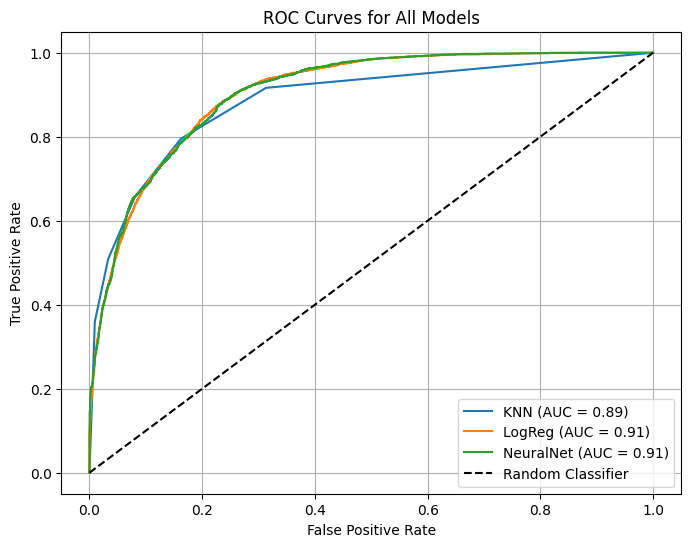

In [ ]:
#ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#predicted prob
y_knn_proba   = knn.predict_proba(X_test_scaled)[:,1]
y_log_proba   = logreg.predict_proba(X_test_scaled)[:,1]
y_nn_proba    = nn.predict(X_test_pp).ravel()

#ROC & AUC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_proba)
fpr_log, tpr_log, _ = roc_curve(y_test, y_log_proba)
fpr_nn,  tpr_nn,  _ = roc_curve(y_test, y_nn_proba)

auc_knn = roc_auc_score(y_test, y_knn_proba)
auc_log = roc_auc_score(y_test, y_log_proba)
auc_nn  = roc_auc_score(y_test, y_nn_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_log, tpr_log, label=f'LogReg (AUC = {auc_log:.2f})')
plt.plot(fpr_nn,  tpr_nn,  label=f'NeuralNet (AUC = {auc_nn:.2f})')

# Diagonal line -> 0.5 line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


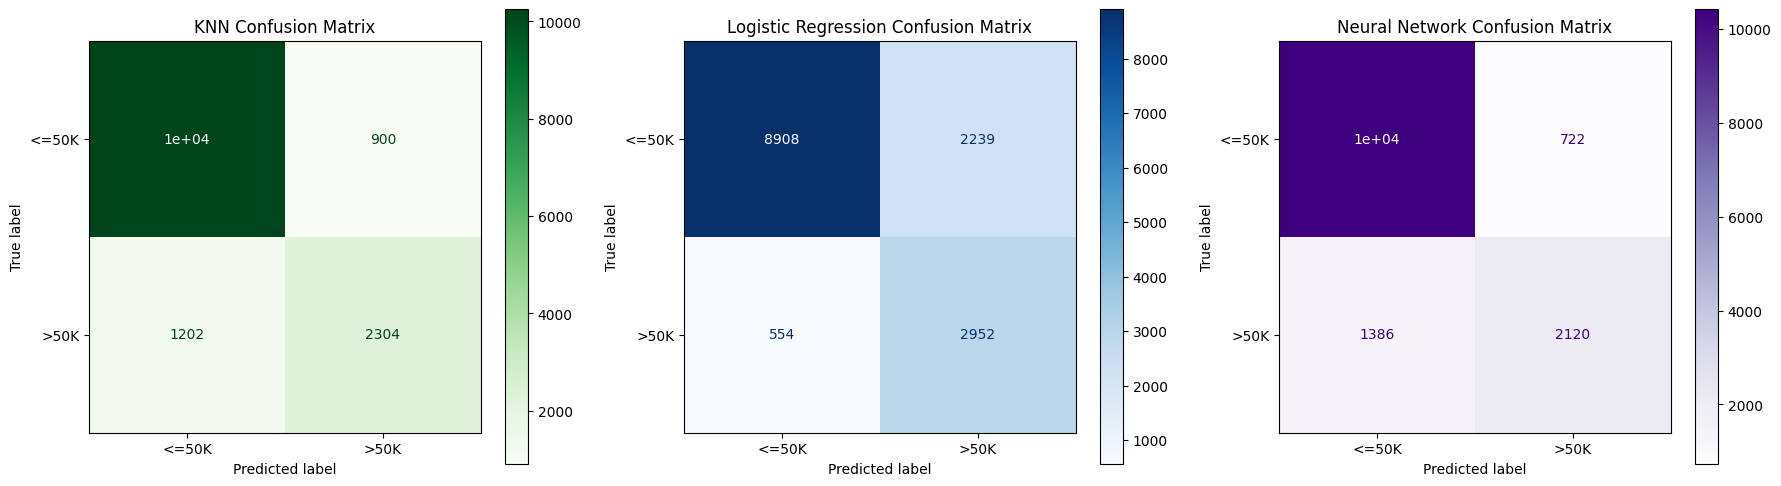

KNN Accuracy:                0.856548147137105
Logistic Regression Accuracy: 0.8093905684842694
Neural Network Accuracy:      0.8561386746741282

KNN Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.92      0.91     11147
        >50K       0.72      0.66      0.69      3506

    accuracy                           0.86     14653
   macro avg       0.81      0.79      0.80     14653
weighted avg       0.85      0.86      0.85     14653

Logistic Regression Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86     11147
        >50K       0.57      0.84      0.68      3506

    accuracy                           0.81     14653
   macro avg       0.76      0.82      0.77     14653
weighted avg       0.85      0.81      0.82     14653

Neural Network Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94    

In [ ]:
#CONFUSION MATRIX, precision,recall,f1-score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report
)
import matplotlib.pyplot as plt
class_labels = ['<=50K', '>50K']

y_pred_knn = knn.predict(X_test_scaled)
y_pred_log = logreg.predict(X_test_scaled)

# NN outputs prob —> threshold  0.5
y_pred_nn_prob = nn.predict(X_test_pp).ravel()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)

# confusiion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=class_labels).plot(
    ax=axes[0], cmap="Greens")
axes[0].set_title("KNN Confusion Matrix")

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=class_labels).plot(
    ax=axes[1], cmap="Blues")
axes[1].set_title("Logistic Regression Confusion Matrix")

cm_nn = confusion_matrix(y_test, y_pred_nn)
ConfusionMatrixDisplay(cm_nn, display_labels=class_labels).plot(
    ax=axes[2], cmap="Purples")
axes[2].set_title("Neural Network Confusion Matrix")

plt.tight_layout()
plt.show()

# accuracy score
print("KNN Accuracy:               ", accuracy_score(y_test, y_pred_knn))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Neural Network Accuracy:     ", accuracy_score(y_test, y_pred_nn))

# classification report
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=class_labels))

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=class_labels))

print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn, target_names=class_labels))


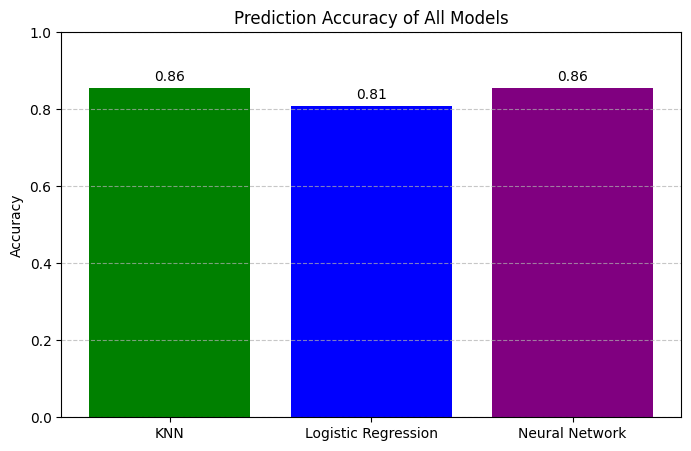

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Calculate accuracies
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_log = accuracy_score(y_test, y_pred_log)
acc_nn  = accuracy_score(y_test, y_pred_nn)


model_names = ['KNN', 'Logistic Regression', 'Neural Network']
accuracies = [acc_knn, acc_log, acc_nn]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies, color=['green', 'blue', 'purple'])
plt.ylim(0.0, 1.0)
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy of All Models')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
